In [6]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random as rnd
import statistics

normal_dist = statistics.NormalDist(0., 1.)

## Modèle Black-Scholes avec structure par termes sur la volatilité

On considère un modèle pseudo Black-Scholes où le processus de prix $(S_t)_t$ d'un actif suit la dynamique suivante avec $S_0 > 0$ déterministe:
$$\mathrm{d}S_t = r S_t \mathrm{d}t + \sigma(t) S_t \mathrm{d} W_t$$
où $\sigma$ est une fonction déterministe du temps. On supposera en particulier que $\sigma$ est linéaire par morceaux et qu'elle vaut:
$$
\sigma(t) = \left\{
\begin{aligned}
\frac{1}{10} && \text{ si } && t < \frac{1}{12}\\
\frac{3}{5} t + \frac{1}{20} && \text{ si } && \frac{1}{12} \leq t < \frac{1}{2}\\
\frac{7}{20} && \text{ si } && t \geq \frac{1}{2}\\
\end{aligned}
\right.
$$

Soient $K > 0$ et $T > 0$. Nous allons chercher à approcher $C_0 = e^{-r T} \mathbb{E}\left[\left(S_T - K\right)^+\right]$ et $P_0 = e^{-r T} \mathbb{E}\left[\left(K - S_T\right)^+\right]$.

Même si on peut trouver directement la loi exacte de $S_T$ (c'est quoi?), on va l'ignorer et procéder de façon plus générale en utilisant un schéma d'Euler-Maruyama et en simulant des trajectoires du modèle discrétisé.

### Un premier schéma numérique...

Nous allons considérer une discrétisation en temps $0 =: t_0 < t_1 < \dots < t_n := T$ à pas constant $h$ (*i.e.* $t_i = i h$ et $h = \frac{T}{n}$). Soient $(\widehat{S}_{t_i})_{0 \leq i\leq }$ des variables aléatoires réelles tels que:
$$\widehat{S}_{t_{i + 1}} = \widehat{S}_{t_i} + r \widehat{S}_{t_i} h + \sigma(t_i) \widehat{S}_{t_i} (W_{t_{i + 1}} - W_{t_i})\quad, \forall i \in \{0, \dots, n - 1\}$$
avec $\widehat{S}_{t_0} = \widehat{S}_0 = S_0$.

1- Ecrire une fonction `sigma` qui prend en argument un instant `t` et donne en sortie la valeur correspondante de $\sigma(t)$.

In [7]:
def sigma(t):
    if t < 1.0 / 12.0:
        return 1.0 / 10.
    if t < 1.0 / 2.0:
        return 3.0 / 5.0 * t + 1.0 / 20.0
    return 7.0 / 20.0

2- Tracez un graphe de votre fonction `sigma` sur l'intervalle $[0, 1]$.

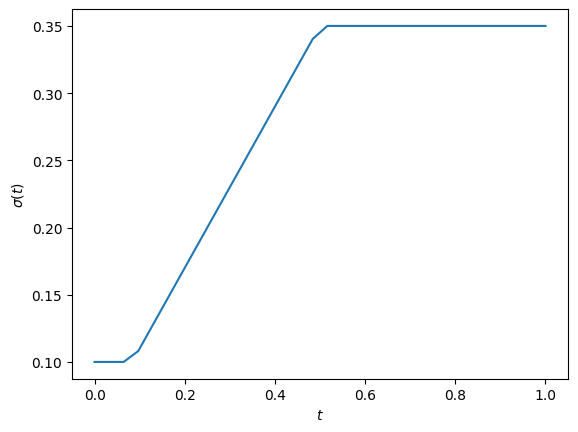

In [8]:
tmp_t_grid = np.linspace(0., 1., 32)
tmp_sigma_values = [sigma(t) for t in tmp_t_grid]
plt.plot(tmp_t_grid, tmp_sigma_values)
plt.xlabel('$t$')
plt.ylabel(r'$\sigma(t)$');

3- Ecrire une fonction `single_step` qui prend en entrée `t` (censé jouer le rôle de $t_i$), `x` (censé jouer le rôle de $\widehat{S}_{t_i}$), `r`, `h` et qui sort une réalisation de $\widehat{S}_{t_{i + 1}}$ sachant $\widehat{S}_{t_i} = x$. Vous allez devoir en particulier vous servir de la fonction `gauss` du module `random` importé sous l'alias `rnd` tout en haut. En particulier, pour générer une réalisation de la loi $\mathcal{N}(0,1)$, il suffit d'appeler `rnd.gauss()`.

In [9]:
def single_step(t, x, r, h):
    return (1. + r * h + sigma(t) * math.sqrt(h) * rnd.gauss()) * x

4- Ecrire une fonction `generate_path` qui prend en entrée `S0`, `r`, `T`, `n` et qui vous donne en sortie une trajectoire de votre schéma numérique sous forme d'une liste constituée de `S0`, suivie d'une réalisation de $\widehat{S}_{t_1}$, suivie d'une réalisation de $\widehat{S}_{t_2}$ sachant $\widehat{S}_{t_1}$, ..., jusqu'à arriver à la maturité $T$ où vous aurez une réalisation de $\widehat{S}_{t_n}$.

In [10]:
def generate_path(S0, r, T, n):
    h = T / n
    path = [None] * (n + 1)
    t = 0.
    S = S0
    path[0] = S
    for i in range(n):
        S = single_step(t, S, r, h)
        path[i + 1] = S
        t += h
    return path

5- Tracez par exemple 16 trajectoires en prenant $S_0 = 1.$, $r = 0.02$, $T = 1$ et $n = 128$.

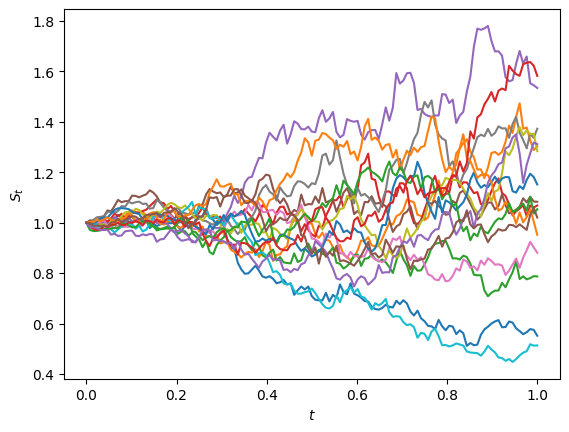

In [11]:
tmp_t_grid = np.linspace(0., 1., 129)
for i in range(16):
    plt.plot(tmp_t_grid, generate_path(1., 0.02, 1., 128))
plt.xlabel('$t$')
plt.ylabel(r'$S_t$');

5- Donner deux estimateurs Monte Carlo des prix $C_0$ et $P_0$. Implémentez-les sous la forme d'une seule fonction `price_call_put` qui prend en entrée `S0`, `r`, `T` `K`, `n`, un nombre `num_paths` de trajectoires, un booléen `call_put` ainsi qu'un seuil de risque `alpha` et qui donne en sortie une estimation par Monte Carlo de $C_0$ si le booléen est à `True` et de $P_0$ sinon, et également une paire constituée des deux bornes d'un intervalle de confiance approché au seuil de confiance $1 - \alpha$.

In [12]:
def price_call_put(S0, r, T, K, n, num_paths, call_put, alpha):
    acc = 0.0
    acc_squares = 0.0
    for i in range(num_paths):
        ST = generate_path(S0, r, T, n)[-1]
        payoff = max(ST - K, 0.) if call_put else max(K - ST, 0.)
        acc += payoff
        acc_squares += payoff * payoff
    acc *= math.exp(-r * T) / num_paths
    acc_squares *= math.exp(-2.0 * r * T) / num_paths
    stdev = math.sqrt(acc_squares - acc * acc)
    z = normal_dist.inv_cdf(1.0 - 0.5 * alpha)
    half_length = z * stdev / math.sqrt(num_paths)
    return acc, (acc - half_length, acc + half_length)

6- Ecrivez une fonction `closed_formula_price` qui prend en entrée `S0`, `r`, `T`, `K` et qui implémente la formule fermée de Black-Scholes pour le prix du call européen vanille considéré. On rappelle que ce prix s'écrit (comment peut-on le retrouver par ailleurs à partir de la formule de Black-Scholes standard?) $$S_0\cdot F_{N(0,1)}(d_1) - K \cdot e^{-rT} \cdot F_{N(0,1)}(d_2)$$
où
$$d_1 = \frac{\ln\left(\frac{S_0}{K}\right) + r T + \frac{1}{2}I_T}{\sqrt{I_T}}$$
$$d_2 = d_1 - \sqrt{I_T}$$
$$I_T = \int_0^T \sigma^2(t) \mathrm{d}t$$

et comparez avec ce que vous obtenez par Monte Carlo avec un nombre de trajectoires égal à $16384$. On prendra $S_0 = 1.$, $r = 0.02$, $T = 1$, $K = 1.03$ et $n = 128$. Vous choisirez $\alpha = 0.025$ pour avoir également un intervalle de confiance à 97.5%.

Il vous faudra bien-sûr calculer au préalable $\int_0^T \sigma^2(t) \mathrm{d}t$ sous forme fermée (que vous implémenterez ensuite dans une fonction utilitaire `sigma_square_integral(T)` par exemple).

Nous avons:

$$
I(T) = \left\{
\begin{aligned}
\frac{1}{100} T && \text{ si } && T < \frac{1}{12}\\
\frac{3}{25} T^3 + \frac{3}{100} T^2 + \frac{1}{400} T + \frac{1}{2880} && \text{ si } && \frac{1}{12} \leq T < \frac{1}{2}\\
\frac{49}{400} T - \frac{107}{2880} && \text{ si } && T \geq \frac{1}{2}\\
\end{aligned}
\right.
$$

In [13]:
def sigma_square_integral(T):
    if T < 1 / 12:
        return T / 100.0
    if T < 0.5:
        return 3.0 / 25.0 * T**3 + 3.0 / 100.0 * T**2 + T / 400.0 + 1.0 / 2880
    return 49.0 / 400.0 * T - 107.0 / 2880.0

def closed_formula_price(S0, r, T, K):
    I = sigma_square_integral(T)
    sqrt_I = math.sqrt(I)
    d1 = (math.log(S0 / K) + r * T) / sqrt_I + 0.5 * sqrt_I
    d2 = d1 - sqrt_I
    return S0 * normal_dist.cdf(d1) - K * math.exp(-r * T) * normal_dist.cdf(d2)

In [14]:
price_call_put(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

(0.11166859037298703, (0.10816380489296899, 0.11517337585300506))

In [15]:
closed_formula_price(1.0, 0.02, 1.0, 1.03)

0.11195226023307808

7- Ecrivez de nouvelles versions `single_step_anti`, `generate_path_anti` et `price_call_put_anti` de respectivement `single_step`, `generate_path` et `price_call_put` qui utilisent des variables antithétiques. Sortir une nouvelle estimation de $C_0$ et son intervalle de confiance. Comparez avec les versions non-antithétiques. Conclusion?

In [11]:
def single_step_anti(t, x, x_anti, r, h):
    Z = rnd.gauss()
    capi = 1. + r * h
    vol_sqrt_h = sigma(t) * math.sqrt(h)
    return (capi + vol_sqrt_h * Z) * x, (capi - vol_sqrt_h * Z) * x_anti

In [12]:
def generate_paths_pair_anti(S0, r, T, n):
    h = T / n
    path = [None] * (n + 1)
    path_anti = [None] * (n + 1)
    t = 0.
    S = S0
    S_anti = S0
    path[0] = S
    path_anti[0] = S_anti
    for i in range(n):
        S, S_anti = single_step_anti(t, S, S_anti, r, h)
        path[i + 1] = S
        path_anti[i + 1] = S_anti
        t += h
    return path, path_anti

In [13]:
def price_call_put_anti(S0, r, T, K, n, num_paths, call_put, alpha):
    assert num_paths % 2 == 0
    acc = 0.0
    acc_squares = 0.0
    half_num_paths = num_paths // 2
    for i in range(half_num_paths):
        paths_pair = generate_paths_pair_anti(S0, r, T, n)
        ST = paths_pair[0][-1]
        ST_anti = paths_pair[1][-1]
        payoff = (max(ST - K, 0.), max(ST_anti - K, 0.)) if call_put else (max(K - ST, 0.), max(K - ST_anti, 0.))
        avg_payoff = 0.5 * (payoff[0] + payoff[1])
        acc += avg_payoff
        acc_squares += avg_payoff * avg_payoff
    acc *= math.exp(-r * T) / half_num_paths
    acc_squares *= math.exp(-2.0 * r * T) / half_num_paths
    stdev = math.sqrt(acc_squares - acc * acc)
    z = normal_dist.inv_cdf(1.0 - 0.5 * alpha)
    half_length = z * stdev / math.sqrt(half_num_paths)
    return acc, (acc - half_length, acc + half_length)

In [14]:
price_call_put_anti(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

(0.11106121841839958, (0.10812543354927834, 0.11399700328752083))

Comparez les tailles des intervalles de confiance entre la version avec et sans variables antithétiques pour le même nombre total de trajectoires (attention: avec la méthode antithétique, pour $N$ simulations indépendantes vous aurez $N$ simulations antithétiques supplémentaires).

### Un meilleur schéma

Le schéma numérique utilisé ci-dessus a un défaut majeur qui est que dans celui-ci l'action peut avoir une valeur négative avec une probabilité non-nulle (se manifestera surtout lorsque la volatilité est grande et que le pas de temps n'est pas suffisamment petit).

Réécrivez vos fonctions ci-dessus en remplaçant le schéma numérique utilisé jusqu'ici par sa version en log-espace, i.e.:

$$\log(\widehat{S}_{t_{i + 1}}) = \log(\widehat{S}_{t_i}) + (r - \frac{\sigma(t_i)^2}{2}) h + \sigma(t_i) (W_{t_{i + 1}} - W_{t_i})\quad, \forall i \in \{0, \dots, n - 1\}$$

In [15]:
def single_step_log(t, x, r, h):
    vol = sigma(t)
    return x + (r - 0.5 * vol * vol) * h + vol * math.sqrt(h) * rnd.gauss()

def generate_path_log(logS0, r, T, n):
    h = T / n
    path = [None] * (n + 1)
    t = 0.
    logS = logS0
    path[0] = logS
    for i in range(n):
        logS = single_step_log(t, logS, r, h)
        path[i + 1] = logS
        t += h
    return path

def price_call_put_log(S0, r, T, K, n, num_paths, call_put, alpha):
    acc = 0.0
    acc_squares = 0.0
    logS0 = math.log(S0)
    for i in range(num_paths):
        ST = math.exp(generate_path_log(logS0, r, T, n)[-1])
        payoff = max(ST - K, 0.) if call_put else max(K - ST, 0.)
        acc += payoff
        acc_squares += payoff * payoff
    acc *= math.exp(-r * T) / num_paths
    acc_squares *= math.exp(-2.0 * r * T) / num_paths
    stdev = math.sqrt(acc_squares - acc * acc)
    z = normal_dist.inv_cdf(1.0 - 0.5 * alpha)
    half_length = z * stdev / math.sqrt(num_paths)
    return acc, (acc - half_length, acc + half_length)

In [16]:
price_call_put_log(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

(0.11338504184015774, (0.10985671008140675, 0.11691337359890873))

In [17]:
# et pour les version antithétiques:

def single_step_anti_log(t, x, x_anti, r, h):
    Z = rnd.gauss()
    vol = sigma(t)
    drift_term = (r - 0.5 * vol * vol) * h
    vol_sqrt_h = vol * math.sqrt(h)
    return x + drift_term + vol_sqrt_h * Z, x_anti + drift_term - vol_sqrt_h * Z

def generate_paths_pair_anti_log(logS0, r, T, n):
    h = T / n
    path = [None] * (n + 1)
    path_anti = [None] * (n + 1)
    t = 0.
    logS = logS0
    logS_anti = logS0
    path[0] = logS
    path_anti[0] = logS_anti
    for i in range(n):
        logS, logS_anti = single_step_anti_log(t, logS, logS_anti, r, h)
        path[i + 1] = logS
        path_anti[i + 1] = logS_anti
        t += h
    return path, path_anti

def price_call_put_anti_log(S0, r, T, K, n, num_paths, call_put, alpha):
    assert num_paths % 2 == 0
    acc = 0.0
    acc_squares = 0.0
    half_num_paths = num_paths // 2
    logS0 = math.log(S0)
    for i in range(half_num_paths):
        paths_pair = generate_paths_pair_anti_log(logS0, r, T, n)
        ST = math.exp(paths_pair[0][-1])
        ST_anti = math.exp(paths_pair[1][-1])
        payoff = (max(ST - K, 0.), max(ST_anti - K, 0.)) if call_put else (max(K - ST, 0.), max(K - ST_anti, 0.))
        avg_payoff = 0.5 * (payoff[0] + payoff[1])
        acc += avg_payoff
        acc_squares += avg_payoff * avg_payoff
    acc *= math.exp(-r * T) / half_num_paths
    acc_squares *= math.exp(-2.0 * r * T) / half_num_paths
    stdev = math.sqrt(acc_squares - acc * acc)
    z = normal_dist.inv_cdf(1.0 - 0.5 * alpha)
    half_length = z * stdev / math.sqrt(half_num_paths)
    return acc, (acc - half_length, acc + half_length)

In [18]:
price_call_put_anti_log(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

(0.11161741531724774, (0.1087421693856387, 0.11449266124885678))

Pricer un put avec les mêmes paramètres et utilisez la parité call-put pour en déduire le prix du call associé. Comparez les intervalles de confiance obtenus pour le call précédemment et cette fois-ci en priçant le put. Conclusion? (indice: il faut y voir une variable de contrôle...)

In [19]:
tmp_put_result = price_call_put_anti_log(1.0, 0.02, 1.0, 1.03, 128, 16384, False, 0.025)
call_minus_put = 1.0 - 1.03 * math.exp(-0.02)
print(f'price using put-call parity: {call_minus_put + tmp_put_result[0]}')
print(f'CI: {call_minus_put + tmp_put_result[1][0], call_minus_put + tmp_put_result[1][1]}')

price using put-call parity: 0.11137069546642635
CI: (0.10988590545727656, 0.11285548547557614)


## Optimisations

L'implémentation précédente est évidemment lente puisque tout se fait de façon séquentielle avec des boucles for qui sont en général lentes sur Python. On considérera cette fois-ci le schéma en log-espace.

Réécrivez vos fonctions de façon vectorielle en utilisant le module `numpy`.

Notez que pour pricer notre produit, nous n'avons nullement besoin de garder en mémoire tous les instants intermédiaires, puisqu'on n'a besoin que des valeurs terminales. Vous pouvez donc à chaque pas de temps écraser les valeurs précédentes par les nouvelles valeurs.

In [20]:
def single_step_log_vec(t, x, r, h, num_paths):
    vol = sigma(t)
    x += (r - 0.5 * vol * vol) * h + vol * math.sqrt(h) * np.random.standard_normal(num_paths)

def generate_ST_log_vec(logS0, r, T, n, num_paths):
    h = T / n
    logS = np.empty(num_paths)
    logS[:] = logS0
    t = 0.0
    for i in range(n):
        single_step_log_vec(t, logS, r, h, num_paths)
        t += h
    return logS

def price_call_put_log_vec(S0, r, T, K, n, num_paths, call_put, alpha):
    ST = np.exp(generate_ST_log_vec(math.log(S0), r, T, n, num_paths))
    payoffs = np.maximum(ST - K, 0.0) if call_put else np.maximum(K - ST, 0.0)
    discount = math.exp(-r * T)
    price = discount * payoffs.mean()
    stdev = discount * payoffs.std()
    z = normal_dist.inv_cdf(1.0 - 0.5 * alpha)
    half_length = z * stdev / math.sqrt(num_paths)
    return price, (price - half_length, price + half_length)

In [21]:
price_call_put_log_vec(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

(np.float64(0.11137897045241209),
 (np.float64(0.10790486076120932), np.float64(0.11485308014361485)))

Comparez les temps d'exécution (voir TPs précédents pour l'usage de `%%timeit`).

In [22]:
%%timeit
price_call_put_log(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

880 ms ± 36.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
%%timeit
price_call_put_log_vec(1.0, 0.02, 1.0, 1.03, 128, 16384, True, 0.025)

34.3 ms ± 724 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


On obtient ici facilement un facteur de speed-up de x26 en réécrivant nos codes sous forme vectorielle. Le calcul se fait toujours en série, mais les boucles `for` internes de numpy se font dans du code déjà compilé, et `numpy` utilisera également les instructions AVX2 ou AVX512 de votre CPU Intel (ou équivalent Arm) pour traiter par paquet de 4 ou 8 nombres de 64 bits. Mais le code n'est pas encore parallélisé.

**Exercice (à faire chez soi ou en classe pour les plus rapides):** Proposez une stratégie de parallélisation en exploitant ce que vous avez vu dans les TPs précédents. Vous aurez besoin de générer correctement les nombres aléatoires pour éviter que deux Monte-Carlos parallèles n'utilisent les mêmes nombres aléatoires, voir https://numpy.org/doc/2.4/reference/random/parallel.html#jumping-the-bitgenerator-state pour faire des sauts dans un générateur aléatoire supportant cette fonctionnalité.